In [2]:
!pip install pandas numpy matplotlib seaborn scipy
!pip install pymatgen

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.4/883.4 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 77.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 120.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 7.6 MB/s eta 0:00:00
  Created wheel for bibtexparser: filename=bibtexparser-1.4.4-py3-none-any.whl size=43609 sha256=a120a1c1c2e6139ee672a997533926229a47f363a3c35abb0180dd989aa04d99
  Sto

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

Mounted at /content/drive


## compute `mag_element_fraction`

In [24]:
from pymatgen.core import Composition

magnetic_elements = {'Fe','Co','Ni','Mn','Cr','Cu','V','Gd','Tb','Dy','Ho','Er','Tm','Nd','Sm','Eu','Yb','Ce','Pr'}

def mag_fraction(formula):
    try:
        comp  = Composition(formula)
        total = sum(comp.values())
        mag   = sum(v for el, v in comp.items() if str(el) in magnetic_elements)
        return mag / total
    except:
        return 0.0

# ompute and add 'mag_element_fraction' column
if 'mag_element_fraction' not in df.columns:
    df['mag_element_fraction'] = df['formula'].apply(mag_fraction)

In [27]:
def run_kruskal_posthoc(feature_col, label, ordering_col='ordering',groups=('FM','AFM','FiM','NM')):

    # grab only the columns we need and drop missing values
    data = df[[ordering_col, feature_col]].dropna()
    group_data = {g: data[data[ordering_col] == g][feature_col].values
                  for g in groups}
    group_data = {g: v for g, v in group_data.items() if len(v) > 0}
    present = list(group_data.keys())

    # run kruskal-wallis across all groups
    stat_kw, p_kw = stats.kruskal(*[group_data[g] for g in present])

    print(f"\n{label}")
    print(f"Kruskal-Wallis  H = {stat_kw:.4f},  p = {p_kw:.2e}")
    for g in present:
        print(f"  {g}: n={len(group_data[g]):,}  " f"median={np.median(group_data[g]):.4f}  "f"mean={np.mean(group_data[g]):.4f}")

    if p_kw < 0.05:
        print("\nat least one group differs significantly")
    else:
        print("\nno significant difference detected")

    # pairwise mann-whitney to see which specific groups differ
    rows = []
    for g1, g2 in combinations(present, 2):
        _, p_mw = stats.mannwhitneyu(group_data[g1], group_data[g2],
                                     alternative='two-sided')
        rows.append({'group 1': g1, 'group 2': g2, 'p-value': p_mw, 'significant': p_mw < 0.05})
    posthoc_df = pd.DataFrame(rows)

    print("\nwhich pairs are different?")
    print(posthoc_df.to_string(index=False))

    return stat_kw, p_kw, posthoc_df, group_data

## H1 — `MagpieData mean NUnfilled` across ordering types

**Hypotheses**
- **H0:** The distribution of `MagpieData mean NUnfilled` is the same across FM, AFM, FiM, and NM materials.  
- **H1:** At least one ordering type has a different NUnfilled distribution — meaning NUnfilled is associated with magnetic ordering / magnetization.

In [10]:
feature1 = 'MagpieData mean NUnfilled'

stat1, p1, posthoc1, gdata1 = run_kruskal_posthoc(
    feature_col=feature1,
    label=f"H1: {feature1} across ordering types"
)


H1: MagpieData mean NUnfilled across ordering types
Kruskal-Wallis  H = 879.8470,  p = 2.08e-190
  FM: n=5,000  median=2.5000  mean=2.9332
  AFM: n=3,415  median=2.3846  mean=2.5994
  FiM: n=5,000  median=2.9236  mean=3.5383
  NM: n=5,000  median=2.4679  mean=2.7734

 at least one group differs significantly

which pairs are different?
group 1 group 2       p-value  significant
     FM     AFM  1.046496e-10         True
     FM     FiM  7.757323e-94         True
     FM      NM  5.111024e-08         True
    AFM     FiM 1.658130e-153         True
    AFM      NM  6.413517e-01        False
    FiM      NM 1.582284e-122         True


/tmp/ipykernel_7399/880304203.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data1, x='ordering', y=feature1,


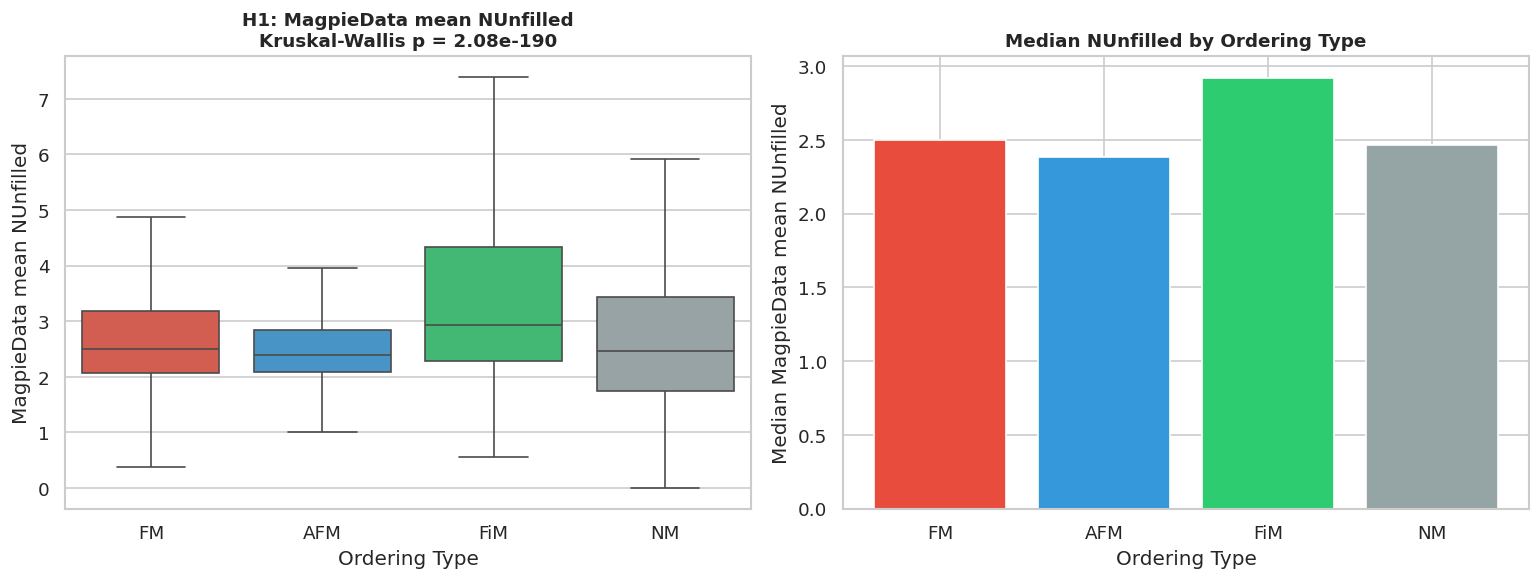

In [11]:
colors = {'FM':'#e74c3c', 'AFM':'#3498db', 'FiM':'#2ecc71', 'NM':'#95a5a6'}
order_present1 = [g for g in ['FM','AFM','FiM','NM'] if g in gdata1]
plot_data1 = df[df['ordering'].isin(order_present1)][['ordering', feature1]].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=plot_data1, x='ordering', y=feature1, order=order_present1, palette=colors, ax=axes[0], showfliers=False)
axes[0].set_title(f'H1: {feature1}\nKruskal-Wallis p = {p1:.2e}',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Ordering Type')
axes[0].set_ylabel(feature1)

medians1 = {g: np.median(v) for g, v in gdata1.items()}
axes[1].bar(medians1.keys(), medians1.values(), color=[colors.get(g, '#aaa') for g in medians1])
axes[1].set_title('Median NUnfilled by Ordering Type', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Ordering Type')
axes[1].set_ylabel(f'Median {feature1}')

plt.tight_layout()
plt.savefig('test1_nunfilled.png', bbox_inches='tight')
plt.show()

## H2 — `MagpieData mean NdUnfilled` across ordering types

**Hypotheses**
- **H0:** The distribution of `MagpieData mean NdUnfilled` is the same across FM, AFM, FiM, and NM materials.  
- **H1:** At least one ordering type has a different NdUnfilled distribution — meaning NdUnfilled is associated with magnetic ordering /magnetization.

In [12]:
feature2 = 'MagpieData mean NdUnfilled'
stat2, p2, posthoc2, gdata2 = run_kruskal_posthoc( feature_col=feature2,label=f"H2: {feature2} across ordering types")


H2: MagpieData mean NdUnfilled across ordering types
Kruskal-Wallis  H = 2255.5800,  p = 0.00e+00
  FM: n=5,000  median=0.8000  mean=1.0902
  AFM: n=3,415  median=0.7273  mean=0.9693
  FiM: n=5,000  median=1.3333  mean=1.7891
  NM: n=5,000  median=0.0000  mean=0.8501

 at least one group differs significantly

which pairs are different?
group 1 group 2       p-value  significant
     FM     AFM  8.687986e-02        False
     FM     FiM 1.176107e-124         True
     FM      NM 2.665364e-169         True
    AFM     FiM 8.132656e-133         True
    AFM      NM 1.201922e-162         True
    FiM      NM  0.000000e+00         True


/tmp/ipykernel_7399/2435470286.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data2, x='ordering', y=feature2,


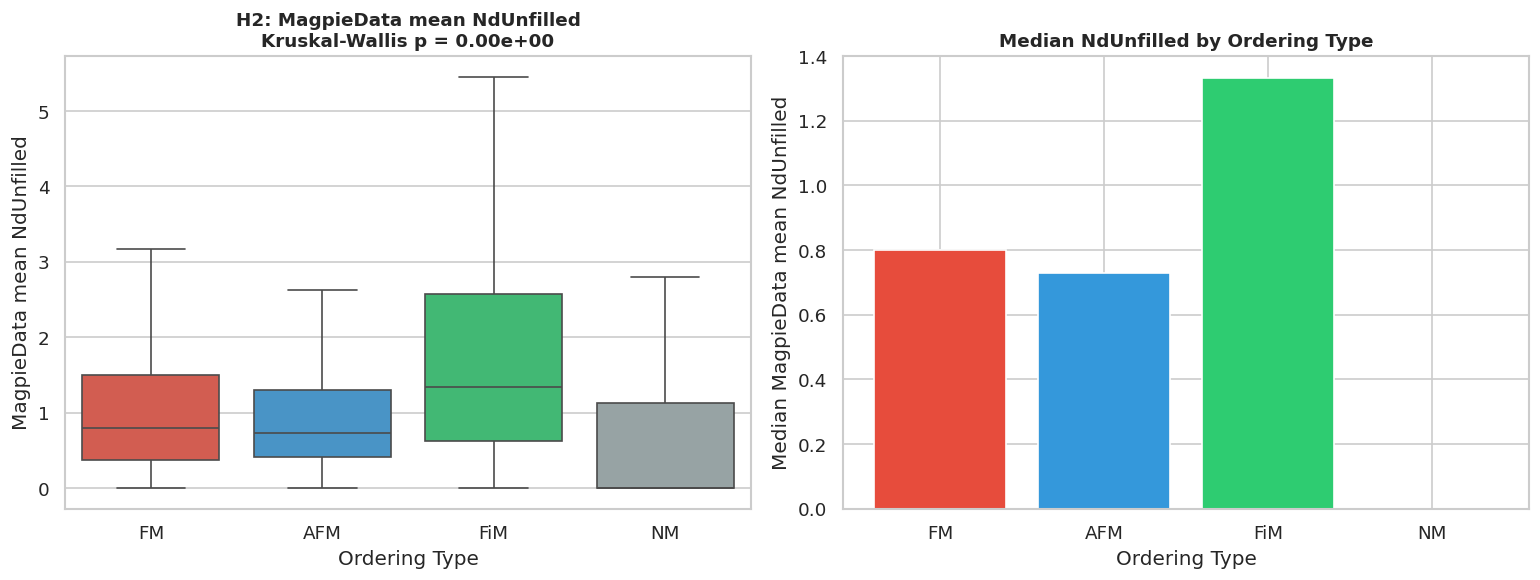

In [14]:
order_present2 = [g for g in ['FM','AFM','FiM','NM'] if g in gdata2]
plot_data2 = df[df['ordering'].isin(order_present2)][['ordering', feature2]].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=plot_data2, x='ordering', y=feature2, order=order_present2, palette=colors, ax=axes[0], showfliers=False)
axes[0].set_title(f'H2: {feature2}\nKruskal-Wallis p = {p2:.2e}', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Ordering Type')
axes[0].set_ylabel(feature2)

medians2 = {g: np.median(v) for g, v in gdata2.items()}
axes[1].bar(medians2.keys(), medians2.values(), color=[colors.get(g, '#aaa') for g in medians2])
axes[1].set_title('Median NdUnfilled by Ordering Type', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Ordering Type')
axes[1].set_ylabel(f'Median {feature2}')

plt.tight_layout()
plt.savefig('test2_ndunfilled.png', bbox_inches='tight')
plt.show()

## H3 — Band Gap: Magnetic vs Non-Magnetic

**Hypotheses**
- **H0:** Magnetic (FM+AFM+FiM) and non-magnetic (NM) materials have the same band gap distribution.  
- **H1:** They are different (two-sided).

In [20]:
magnetic= df[df['ordering'].isin(['FM','AFM','FiM'])]['band_gap'].dropna()
nonmagnetic= df[df['ordering'] == 'NM']['band_gap'].dropna()

stat3, p3 = stats.mannwhitneyu(magnetic, nonmagnetic, alternative='two-sided')

print("H3: Band Gap — Magnetic vs Non-Magnetic")

print(f"U statistic: {stat3:.4f}")
print(f"p-value: {p3:.2e}  (two-sided)")
print(f"\nMagnetic median band gap: {magnetic.median():.4f} eV")
print(f"Non-magnetic median band gap: {nonmagnetic.median():.4f} eV")
metal_frac_mag = (magnetic    == 0).mean()
metal_frac_nm  = (nonmagnetic == 0).mean()
print(f"\nFraction metallic (gap=0) — Magnetic: {metal_frac_mag:.2%},  NM: {metal_frac_nm:.2%}")
if p3 < 0.05:
    print("\nResult: Reject H0 — magnetic and non-magnetic materials have significantly different band gap distributions.")
else:
    print("\nFail to reject H0.")

H3: Band Gap — Magnetic vs Non-Magnetic
U statistic: 27336455.5000
p-value: 5.58e-94  (two-sided)

Magnetic median band gap: 0.0000 eV
Non-magnetic median band gap: 0.4810 eV

Fraction metallic (gap=0) — Magnetic: 50.61%,  NM: 44.24%

Result: Reject H₀ — magnetic and non-magnetic materials have significantly different band gap distributions.


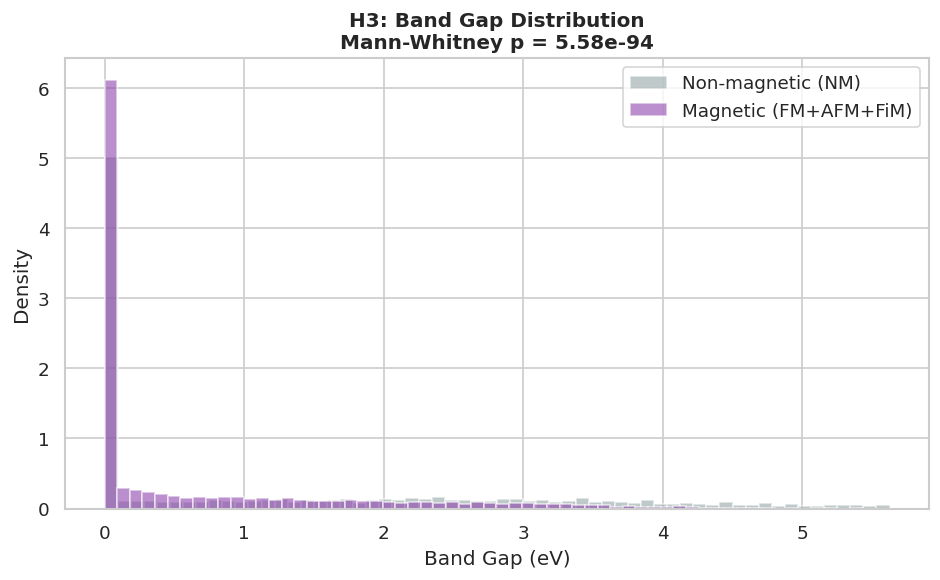

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
upper = max(magnetic.quantile(0.98), nonmagnetic.quantile(0.98))
ax.hist(nonmagnetic[nonmagnetic <= upper], bins=60, alpha=0.6, color='#95a5a6', label='Non-magnetic (NM)', density=True)
ax.hist(magnetic[magnetic <= upper], bins=60, alpha=0.6, color='#8e44ad', label='Magnetic (FM+AFM+FiM)', density=True)
ax.set_title(f'H3: Band Gap Distribution\nMann-Whitney p = {p3:.2e}', fontsize=12, fontweight='bold')
ax.set_xlabel('Band Gap (eV)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig('test3_bandgap.png', bbox_inches='tight')
plt.show()

## H4 — Spearman: Magnetic Element Fraction vs Magnetization
**Hypotheses**
- **H0:** No monotonic relationship between magnetic element fraction and magnetization (ρ = 0).  
- **H1:** A significant positive monotonic relationship exists (ρ > 0).

In [25]:
clean4 = df[['mag_element_fraction', 'magnetization_per_fu']].dropna()
rho4, p4 = stats.spearmanr(clean4['mag_element_fraction'],clean4['magnetization_per_fu'])

print("H4: Spearman — Magnetic Element Fraction vs Magnetization")

print(f"Spearman ρ : {rho4:.4f}")
print(f"p-value    : {p4:.2e}")
if p4 < 0.05:
    direction = 'positive' if rho4 > 0 else 'negative'
    print(f"\nResult: Reject H0 — significant {direction} monotonic correlation between magnetic element fraction and magnetization (ρ = {rho4:.3f}).")
else:
    print("\nResult: Fail to reject H0.")

H4: Spearman — Magnetic Element Fraction vs Magnetization
Spearman ρ : 0.3483
p-value    : 0.00e+00

Result: Reject H₀ — significant positive monotonic correlation between magnetic element fraction and magnetization (ρ = 0.348).


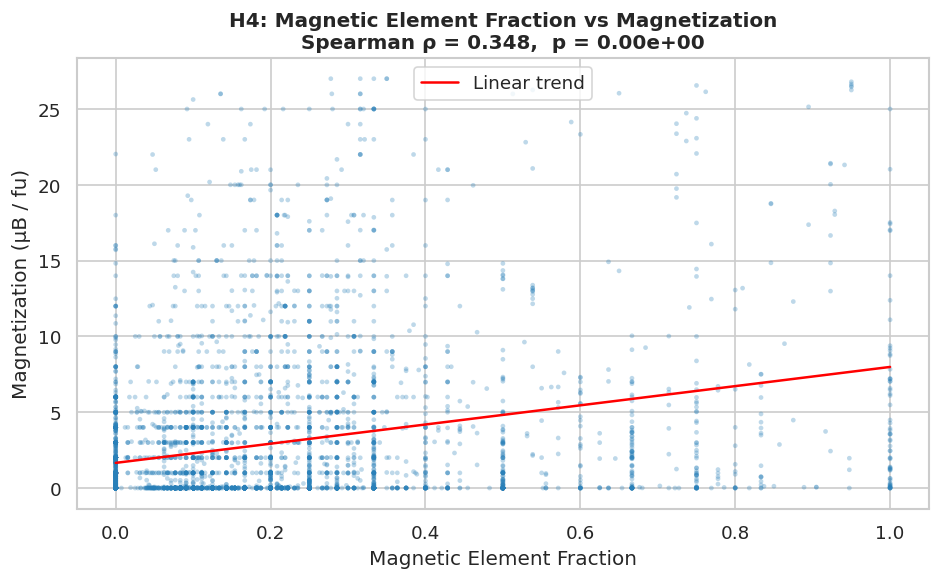

In [26]:
fig, ax= plt.subplots(figsize=(8, 5))
sample4= clean4.sample(min(5000, len(clean4)), random_state=42)
upper4= sample4['magnetization_per_fu'].quantile(0.98)
sample4= sample4[sample4['magnetization_per_fu'] <= upper4]

ax.scatter(sample4['mag_element_fraction'], sample4['magnetization_per_fu'], alpha=0.3, s=8, color='#2980b9', edgecolors='none')
z4 = np.polyfit(sample4['mag_element_fraction'], sample4['magnetization_per_fu'], 1)
ax.plot(sorted(sample4['mag_element_fraction']), np.polyval(z4, sorted(sample4['mag_element_fraction'])), color='red', linewidth=1.5, label='Linear trend')

ax.set_title(f'H4: Magnetic Element Fraction vs Magnetization\n' f'Spearman ρ = {rho4:.3f},  p = {p4:.2e}',fontsize=12, fontweight='bold')
ax.set_xlabel('Magnetic Element Fraction')
ax.set_ylabel('Magnetization (μB / fu)')
ax.legend()
plt.tight_layout()
plt.savefig('test4_spearman_magfrac.png', bbox_inches='tight')
plt.show()